# 06 — Agroforestry suitability map for Kenya

**Goal:** Produce a pixel-wise suitability map across Kenya combining:
1. **CHIRPS** — mean seasonal rainfall (MAM long rains, 1981–2023)
2. **iSDAsoil** — soil texture (sand/silt/clay fractions → USDA texture class)

**Suitability logic (from model results):**
- Each pixel gets a soil texture class → lookup median ΔY from `05_cross_soils` results
- Each pixel gets a mean seasonal rainfall → lookup ΔY scale factor from `03_trait_surface` rainfall sensitivity
- Combined suitability score = sign(ΔY) — or continuous ΔY if ranges overlap

**Requires:**
- `earthengine-api` (`pip install earthengine-api`)
- `geemap` (`pip install geemap`)
- GEE project ID filled in below

In [1]:
import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

GEE_PROJECT = 'evap-and-deform'

ee.Authenticate()
ee.Initialize(project=GEE_PROJECT)
print('GEE initialized.')

GEE initialized.


---
## 1 — Kenya boundary

In [2]:
kenya = (
    ee.FeatureCollection('FAO/GAUL/2015/level0')
    .filter(ee.Filter.eq('ADM0_NAME', 'Kenya'))
    .geometry()
)
print('Kenya boundary loaded.')

Kenya boundary loaded.


---
## 2 — CHIRPS: mean seasonal rainfall (MAMJJA growing season)

Filter to March–August (months 3–8), matching the Krell model growing season (planting day 60 → day 240, lgp=180).  
Sum daily rainfall to seasonal total per year, then take the long-run mean (1981–2023).  
Output: single-band image in mm/season at ~5.5 km resolution.

In [3]:
chirps_daily = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')

# Growing season: March–August (day 60–240, matching Krell model pd_sim=60, lgp=180)
YEAR_START = 1981
YEAR_END   = 2023

def seasonal_sum(year):
    """Return total MAMJJA rainfall for a given year."""
    start = ee.Date.fromYMD(year, 3, 1)
    end   = ee.Date.fromYMD(year, 9, 1)  # exclusive: through Aug 31
    return (
        chirps_daily
        .filterDate(start, end)
        .filterBounds(kenya)
        .sum()
        .set('year', year)
    )

years = ee.List.sequence(YEAR_START, YEAR_END)
annual_mamjja = ee.ImageCollection(years.map(seasonal_sum))

# Long-run mean seasonal rainfall (mm/season)
mean_rainfall = annual_mamjja.mean().rename('mean_seasonal_rf').clip(kenya)

print(f'CHIRPS MAMJJA mean computed ({YEAR_START}–{YEAR_END}).')

CHIRPS MAMJJA mean computed (1981–2023).


---
## 3 — SoilGrids: soil texture classification

Load sand, silt, clay fractions (0–5 cm) from SoilGrids ISRIC (`projects/soilgrids-isric`, 250 m resolution).  
Values are in g/kg — divide by 10 to get %.  
Classify each pixel into a USDA texture class using the texture triangle, then map to a Clapp & Hornberger label.

*Note: iSDAsoil is not available as a public GEE asset; SoilGrids is the standard alternative.*

In [4]:
# SoilGrids 0–5 cm fractions (g/kg → divide by 10 for %)
sand_raw = ee.Image('projects/soilgrids-isric/sand_mean').select('sand_0-5cm_mean').divide(10)
silt_raw = ee.Image('projects/soilgrids-isric/silt_mean').select('silt_0-5cm_mean').divide(10)
clay_raw = ee.Image('projects/soilgrids-isric/clay_mean').select('clay_0-5cm_mean').divide(10)

texture_img = (
    sand_raw.rename('sand')
    .addBands(silt_raw.rename('silt'))
    .addBands(clay_raw.rename('clay'))
    .clip(kenya)
)

print('SoilGrids texture bands loaded.')

sand = texture_img.select('sand')
silt = texture_img.select('silt')
clay = texture_img.select('clay')

# USDA texture triangle → integer class 1–11
# Order: most specific conditions first, then broader
texture_class = (
    ee.Image(5)  # default to loam
    .where(sand.gte(85),                                                          1)   # sand
    .where(sand.gte(70).And(clay.lt(15)),                                         2)   # loamy sand
    .where(clay.lt(20).And(sand.gte(43)).And(silt.lt(50)),                        3)   # sandy loam
    .where(silt.gte(50).And(clay.lt(27)),                                         4)   # silt loam
    .where(clay.gte(7).And(clay.lt(27)).And(silt.gte(28)).And(silt.lt(50)).And(sand.lte(52)), 5)  # loam
    .where(clay.gte(20).And(clay.lt(35)).And(sand.gte(45)).And(silt.lt(28)),      6)   # sandy clay loam
    .where(clay.gte(27).And(clay.lt(40)).And(silt.gte(40)),                       7)   # silty clay loam
    .where(clay.gte(27).And(clay.lt(40)).And(sand.lte(45)),                       8)   # clay loam
    .where(clay.gte(35).And(sand.gte(45)),                                        9)   # sandy clay
    .where(clay.gte(40).And(silt.gte(40)),                                        10)  # silty clay
    .where(clay.gte(40),                                                          11)  # clay
    .rename('texture_class')
    .clip(kenya)
)

# Verify with a sample point (Laikipia: ~37.2% sand, 22.5% silt, 40.3% clay → clay loam/clay)
sample = texture_class.reduceRegion(
    reducer=ee.Reducer.first(),
    geometry=ee.Geometry.Point([36.9, 0.4]),
    scale=250
).getInfo()
print(f'Texture class at Laikipia sample point: {sample}  (expected ~8=clay loam or 11=clay)')

SoilGrids texture bands loaded.


Texture class at Laikipia sample point: {'texture_class': 8}  (expected ~8=clay loam or 11=clay)


---
## 4 — Model lookup tables

Paste in results from:
- `05_cross_soils.ipynb` → median ΔY per texture at baseline rainfall
- `03_trait_surface.ipynb` cell `t42r61s1to` → median ΔY per rainfall level

These are used to assign a suitability score to each pixel.

In [5]:
# ── Soil texture → median ΔY at baseline rainfall (~450 mm/season) ───────────
# From 05_cross_soils.ipynb (lf=1.0, Zr=1500, full system, N=200)
# Textures not in 05_cross_soils are interpolated as mean of nearest neighbours.
SOIL_DY = {
    1:  ('sand',            61),    # from 05_cross_soils
    2:  ('loamy sand',      69),    # interpolated: mean(sand=61, sandy loam=77)
    3:  ('sandy loam',      77),    # from 05_cross_soils
    4:  ('silt loam',       90),    # interpolated: mean(sandy loam=77, loam=102)
    5:  ('loam',            102),   # from 05_cross_soils
    6:  ('sandy clay loam', 109),   # interpolated: mean(loam=102, clay loam=116)
    7:  ('silty clay loam', 109),   # interpolated: mean(loam=102, clay loam=116)
    8:  ('clay loam',       116),   # from 05_cross_soils
    9:  ('sandy clay',       95),   # interpolated: mean(clay loam=116, clay=73)
    10: ('silty clay',       95),   # interpolated: mean(clay loam=116, clay=73)
    11: ('clay',             73),   # from 05_cross_soils
}

# ── Mean seasonal rainfall (mm) → median ΔY ──────────────────────────────────
# From 03_trait_surface.ipynb cell t42r61s1to
# Tree: lf=1.0, Zr=1500, full system (deep roots + HR + shade), loam soil, N=100
# NOTE: ΔY=0 below 338 mm because monoculture crop fails entirely (zero yield)
RF_DY = pd.DataFrame([
    dict(mean_rf=90,   dY=0),
    dict(mean_rf=135,  dY=0),
    dict(mean_rf=180,  dY=0),
    dict(mean_rf=225,  dY=0),
    dict(mean_rf=270,  dY=0),
    dict(mean_rf=338,  dY=111),
    dict(mean_rf=450,  dY=100),
    dict(mean_rf=562,  dY=40),
    dict(mean_rf=675,  dY=12),
    dict(mean_rf=810,  dY=-26),
])

print('SOIL_DY:')
for k, (name, val) in SOIL_DY.items():
    print(f'  {k:2d}  {name:20s}  ΔY={val:+d} kg/ha')
print()
print('RF_DY:')
print(RF_DY.to_string(index=False))

SOIL_DY:
   1  sand                  ΔY=+61 kg/ha
   2  loamy sand            ΔY=+69 kg/ha
   3  sandy loam            ΔY=+77 kg/ha
   4  silt loam             ΔY=+90 kg/ha
   5  loam                  ΔY=+102 kg/ha
   6  sandy clay loam       ΔY=+109 kg/ha
   7  silty clay loam       ΔY=+109 kg/ha
   8  clay loam             ΔY=+116 kg/ha
   9  sandy clay            ΔY=+95 kg/ha
  10  silty clay            ΔY=+95 kg/ha
  11  clay                  ΔY=+73 kg/ha

RF_DY:
 mean_rf  dY
      90   0
     135   0
     180   0
     225   0
     270   0
     338 111
     450 100
     562  40
     675  12
     810 -26


---
## 5 — Suitability map

For each pixel:
1. Look up soil ΔY from texture class
2. Look up rainfall ΔY scale factor (relative to baseline)
3. Suitability = sign of combined ΔY  
   (positive = facilitation expected; negative = competition expected)

**Note:** Run cell 4 lookup tables first.

In [6]:
# ── Soil ΔY image ─────────────────────────────────────────────────────────────
soil_keys   = list(SOIL_DY.keys())
soil_values = [SOIL_DY[k][1] for k in soil_keys]

soil_dY_img = texture_class.remap(soil_keys, soil_values).rename('soil_dY')

# ── Rainfall ΔY image (piecewise linear interpolation) ───────────────────────
# ee.Image has no interpolateLinear — implement manually with .where() chains.
rf_bins    = RF_DY['mean_rf'].tolist()
rf_dY_vals = RF_DY['dY'].tolist()

# Start with the value for rainfall below the first bin
rf_dY_img = ee.Image(float(rf_dY_vals[0])).rename('rf_dY')

# Apply each segment
for i in range(len(rf_bins) - 1):
    x0, x1 = float(rf_bins[i]),    float(rf_bins[i + 1])
    y0, y1 = float(rf_dY_vals[i]), float(rf_dY_vals[i + 1])
    slope   = (y1 - y0) / (x1 - x0)
    segment = mean_rainfall.subtract(x0).multiply(slope).add(y0)
    in_range = mean_rainfall.gte(x0).And(mean_rainfall.lt(x1))
    rf_dY_img = rf_dY_img.where(in_range, segment)

# Clamp values above the last bin to the last ΔY value
rf_dY_img = rf_dY_img.where(
    mean_rainfall.gte(float(rf_bins[-1])),
    float(rf_dY_vals[-1])
).rename('rf_dY')

# ── Combined suitability ──────────────────────────────────────────────────────
suitability = soil_dY_img.add(rf_dY_img).divide(2).rename('suitability')

print('Suitability image computed.')

Suitability image computed.


---
## 6 — Visualize

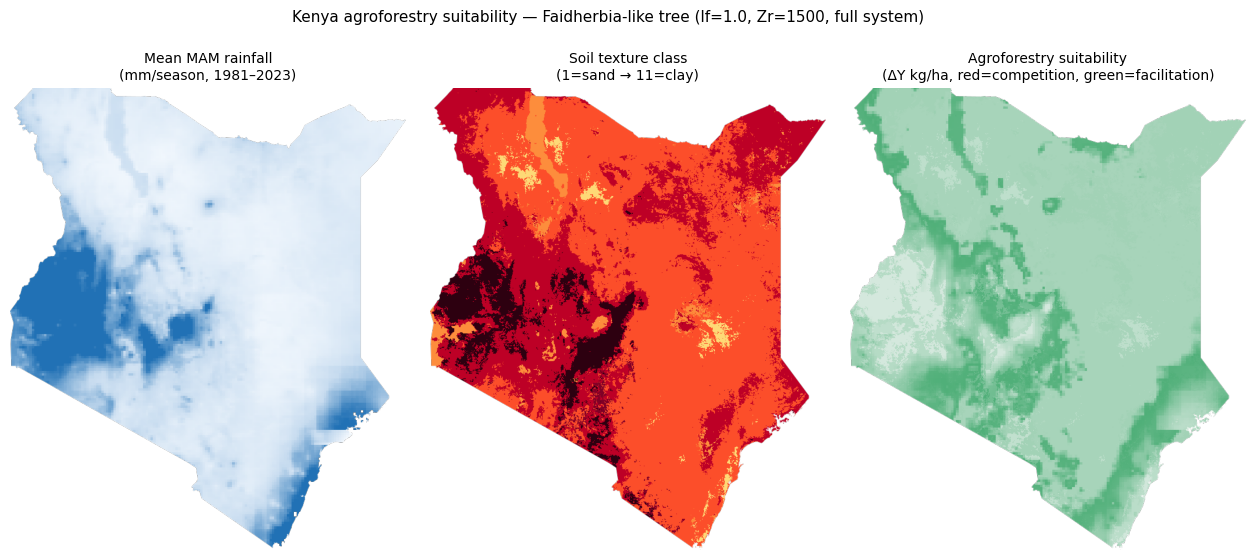

Saved to ../output/06_suitability_map.png


In [7]:
import io
import requests
from PIL import Image as PILImage

def ee_thumbnail(img, vis_params, region, dims=800):
    """Download a GEE image as a PIL image via thumbnail URL."""
    url = img.getThumbURL({**vis_params, 'region': region, 'dimensions': dims, 'format': 'png'})
    resp = requests.get(url)
    return PILImage.open(io.BytesIO(resp.content))

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.subplots_adjust(wspace=0.05)

# Rainfall
axes[0].imshow(ee_thumbnail(
    mean_rainfall,
    {'min': 0, 'max': 800, 'palette': ['f7fbff', 'c6dbef', '2171b5']},
    kenya
))
axes[0].set_title('Mean MAM rainfall\n(mm/season, 1981–2023)', fontsize=10)
axes[0].axis('off')

# Soil texture
axes[1].imshow(ee_thumbnail(
    texture_class,
    {'min': 1, 'max': 11, 'palette': [
        'ffffcc','ffeda0','fed976','feb24c','fd8d3c',
        'fc4e2a','e31a1c','bd0026','800026','54001a','2d0010'
    ]},
    kenya
))
axes[1].set_title('Soil texture class\n(1=sand → 11=clay)', fontsize=10)
axes[1].axis('off')

# Suitability
axes[2].imshow(ee_thumbnail(
    suitability,
    {'min': -150, 'max': 150, 'palette': ['d73027', 'f7f7f7', '1a9850']},
    kenya
))
axes[2].set_title('Agroforestry suitability\n(ΔY kg/ha, red=competition, green=facilitation)', fontsize=10)
axes[2].axis('off')

plt.suptitle('Kenya agroforestry suitability — Faidherbia-like tree (lf=1.0, Zr=1500, full system)',
             fontsize=11, y=1.01)
plt.savefig('../output/06_suitability_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to ../output/06_suitability_map.png')